# Notebook 1: Model Complexity, Underfitting, and Overfitting

*Adapted from: https://github.com/Winston-503/underfitting_vs_overfitting/tree/main*

In this notebook, we will explore one of the most important ideas in machine learning: 
what happens when your model is too simple or too complex for the data you are trying 
to fit. These concepts, underfitting, overfitting, and the bias-variance tradeoff, 
come up in every practical modeling decision, and they apply regardless of whether 
you are working with a linear model or a more complex one.

To make these ideas as clear as possible, we will work with synthetic (artificially 
generated) data rather than a real biological dataset. Synthetic data lets us know 
exactly what the true underlying relationship looks like, which means we can directly 
see when a model is getting it right and when it is failing. In the next notebook, 
you will apply these same ideas to a real biological dataset.

**A loose biological motivation**

Before we generate our data, here is an intuition for the kind of relationship we are 
about to model. Imagine measuring how a compound affects bacterial growth across a 
range of concentrations. At low concentrations, the compound might stimulate growth. 
At higher concentrations, it begins to inhibit it. The relationship between 
concentration and growth is non-monotonic: it does not move consistently in one 
direction. A straight line cannot describe this kind of relationship, and trying to 
fit one would give you a misleading picture of the biology.

The synthetic data we use below has this general shape: it rises, falls, and rises 
again. Keep that image in mind as we work through the exercises.

In [1]:
# Run this cell to load the libraries we need for this notebook.

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error as mse
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


## Part 1: Generating the synthetic dataset

The cell below defines the mathematical function that generates our data and then 
creates a dataset by sampling points from it at random. A small amount of random 
noise is added to each point to mimic the kind of measurement variability you would 
see in a real experiment.

Notice that the function is a cubic polynomial. You do not need to understand the 
math in detail. What matters is that the true relationship between x and y follows 
a specific curve, and our goal will be to see how well different models can recover 
that curve from a limited number of noisy observations.

The dataset is then split into a **training set** (the data the model will learn 
from) and a **test set** (held-out data used to evaluate how well the model 
generalizes to new observations it has never seen).

In [57]:
# This is the true underlying function that generates our data.
# In a real experiment, you would never know this function
# you would only have the observations.

def true_function(x):
    return 0.1*x**3 + 2*x**2 + 7*x + 4 

# Define the range of x values we will sample from
x_min = -15
x_max = 2

# Generate a dataset of 20 observations by sampling x values at random
# and computing y = true_function(x) + some noise
np.random.seed(42)
x = np.random.uniform(low=x_min, high=x_max, size=20)
y = true_function(x) + 3 * np.random.randn(20)

# Split into training (70%) and test (30%) sets
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42)

# Generate smooth x values so we can plot the true function as a curve
x_plot = np.arange(x_min, x_max, step=0.1)
y_true = true_function(x_plot)

print(f"Training samples: {len(x_train)}")
print(f"Test samples: {len(x_test)}")

Training samples: 14
Test samples: 6


Now let's plot the dataset. The blue points are the training observations and the 
green points are the test observations. The gray curve shows the true underlying 
function that generated all of these points.

Notice that the training and test points are scattered around the true curve, not 
sitting exactly on it. That scatter is the noise we added to simulate measurement 
variability.

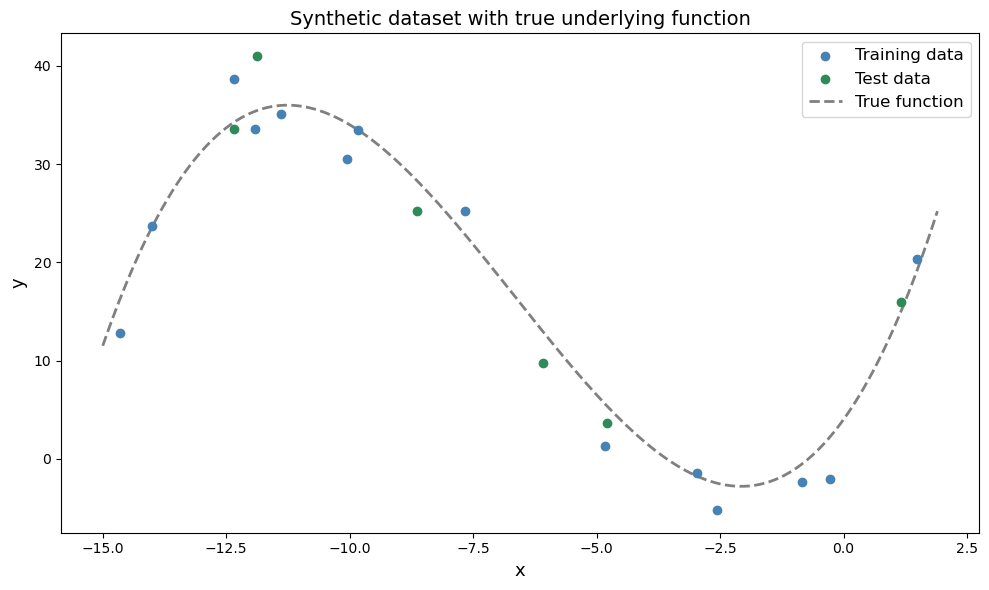

In [58]:
# Plot the dataset with training points, test points, and the true function

plt.figure(figsize=(10, 6))
plt.scatter(x_train, y_train, label="Training data", color='steelblue', zorder=3)
plt.scatter(x_test, y_test, label="Test data", color='seagreen', zorder=3)
plt.plot(x_plot, y_true, color='gray', linestyle='--', label='True function', linewidth=2)
plt.xlabel("x", fontsize=13)
plt.ylabel("y", fontsize=13)
plt.title("Synthetic dataset with true underlying function", fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

## Part 2: What happens when a model is too simple? (Underfitting)

Now that we have our dataset, let's try to fit a model to it. We will start with 
the simplest possible model: a straight line. This is equivalent to a linear 
regression model with a single term.

The cell below fits a degree 1 polynomial (a straight line) to the training data 
and plots the result. Two error values are reported in the plot title:

- **Training error (MSE):** how well the model fits the data it was trained on
- **Test error (MSE):** how well the model predicts the held-out test data

MSE stands for Mean Squared Error. It measures the average squared difference 
between the model's predictions and the actual values. A lower MSE means better 
predictions. For now, focus on the relative difference between training and test 
error rather than the absolute numbers.

In [59]:
# Helper function to fit a polynomial model and plot the result.
# You do not need to modify this function.

def fit_and_plot(x_train, y_train, x_test, y_test, x_plot, y_true, degree, title):
    
    # Build a pipeline: expand features to given polynomial degree,
    # scale them, then fit a linear regression
    model = make_pipeline(
        PolynomialFeatures(degree),
        StandardScaler(),
        LinearRegression()
    )
    model.fit(x_train.reshape(-1, 1), y_train)
    
    # Compute training and test error
    train_mse = mse(y_train, model.predict(x_train.reshape(-1, 1)))
    test_mse  = mse(y_test,  model.predict(x_test.reshape(-1, 1)))
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.scatter(x_train, y_train, label="Training data", color='steelblue', zorder=3)
    plt.scatter(x_test,  y_test,  label="Test data",     color='seagreen',  zorder=3)
    plt.plot(x_plot, model.predict(x_plot.reshape(-1, 1)),
             color='tomato', linewidth=2, label=f"Model (degree {degree})")
    plt.plot(x_plot, y_true, color='gray', linestyle='--',
             label='True function', linewidth=2)
    plt.xlabel("x", fontsize=13)
    plt.ylabel("y", fontsize=13)
    plt.ylim(-7, 42)
    plt.legend(fontsize=12)
    plt.title(f"{title}\nTraining MSE = {train_mse:.2f}   |   Test MSE = {test_mse:.2f}",
              fontsize=13)
    plt.tight_layout()
    plt.show()
    
    return train_mse, test_mse

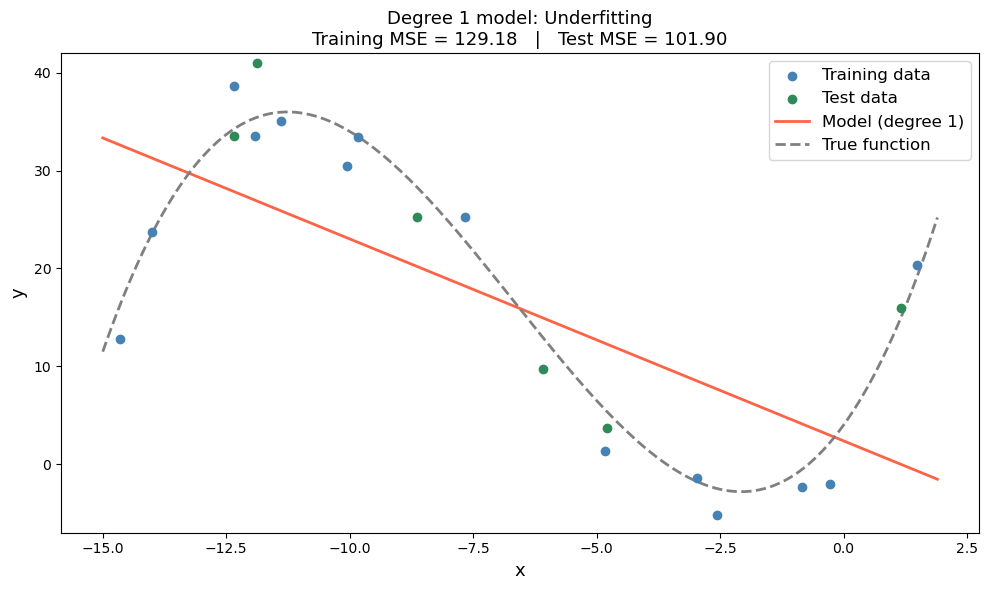

In [60]:
# Fit a degree 1 model (a straight line) to the training data

train_mse_1, test_mse_1 = fit_and_plot(
    x_train, y_train, x_test, y_test, x_plot, y_true,
    degree=1,
    title="Degree 1 model: Underfitting"
)

Look at the plot. The straight line cannot follow the curve in the data at all. 
It underestimates in some regions and overestimates in others because a straight 
line is structurally incapable of representing a relationship that rises and then falls.

Notice also that the training error and the test error are both high and fairly 
close to each other. This is the signature of underfitting: the model is not even 
doing well on the data it was trained on, so there is no reason to expect it to 
do well on new data either.

This is what **high bias** looks like. The model is too rigid: it has committed 
to a form (a straight line) that cannot represent the underlying pattern, no 
matter how much data you give it.

**Try it** Change `degree=1` to `degree=2` in the cell above and re-run it. 
Does the fit improve? Is there still a problem?

## Part 3: Finding a good fit

We have seen that degree 1 is too simple. But what degree is actually appropriate 
for this data? Rather than telling you, we will let you find out.

The cell below is set to `degree=1` as a starting point. Try increasing the degree 
one step at a time and re-running the cell. Watch how the training and test errors 
change as you do. You are looking for the degree where both errors are low and 
reasonably close to each other.

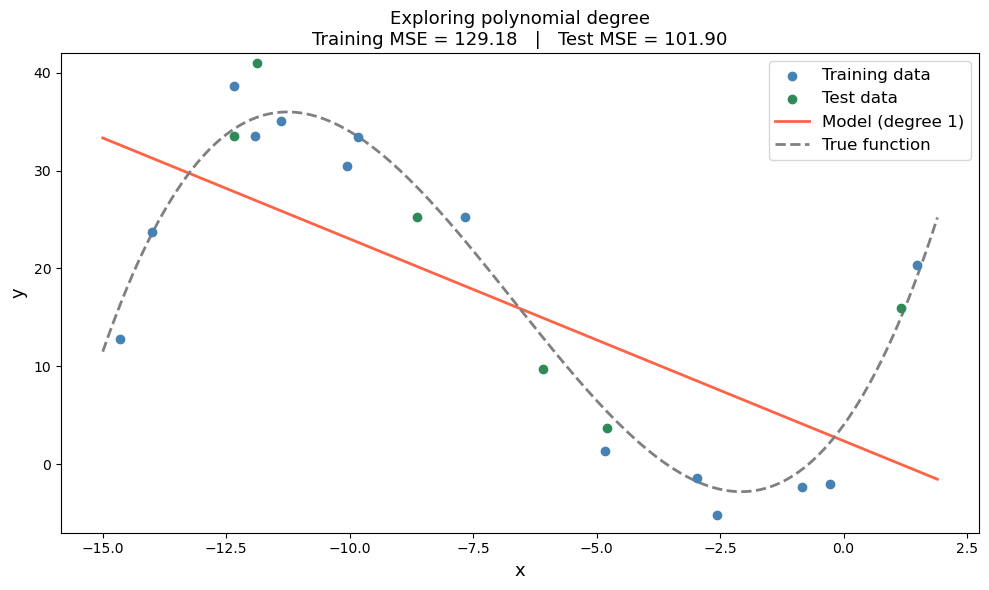

In [61]:
# Change the degree value below and re-run this cell to explore different model fits.
# Start at degree=1 and work upward one step at a time.

train_mse_best, test_mse_best = fit_and_plot(
    x_train, y_train, x_test, y_test, x_plot, y_true,
    degree=1,          # <-- change this value and re-run
    title="Exploring polynomial degree"
)

Once you have found a degree that gives a good fit, note it down. We will 
refer back to it when we look at overfitting in the next section.

**Try it** What degree gave you the lowest test error while keeping the 
training and test errors close together? What did the fitted curve look like 
at that degree compared to degree 1?

## Part 4: What happens when a model is too complex? (Overfitting)

We have seen that a model can be too simple. Now let's look at the opposite 
problem. What happens when we give the model far more flexibility than it needs?

The cell below fits a degree 13 polynomial to the same training data. Run it and 
compare the result to what you saw in Parts 2 and 3.

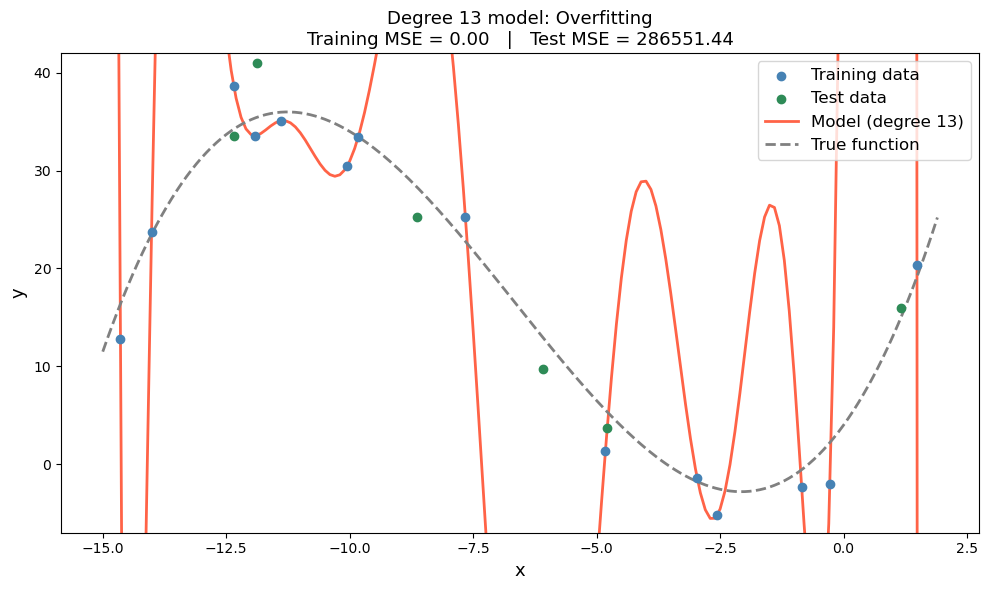

In [62]:
# Fit a degree 13 model to the training data

train_mse_13, test_mse_13 = fit_and_plot(
    x_train, y_train, x_test, y_test, x_plot, y_true,
    degree=13,
    title="Degree 13 model: Overfitting"
)

The red curve now twists sharply to pass through or near every individual 
training point. The training error is very low, which might look like good 
news at first. But look at the test error: it is much higher than the training 
error, and much higher than it was for the degree 3 model.

This is the signature of overfitting. The model has learned the training data 
almost perfectly, including the noise, the random scatter that is specific to 
these training observations and does not reflect any real biological 
pattern. When it encounters the test points it has never seen, it performs 
poorly because those random quirks it memorized do not appear in new data.

This is what **high variance** looks like. The model is so flexible that small 
changes in the training data would produce a completely different fitted curve. 
It is sensitive to the specific samples it happened to see during training 
rather than the underlying relationship.

**Try it** Change `degree=13` to a few other values, for example `degree=6` 
or `degree=10`. At what degree do you start to see the training and test errors 
diverge noticeably?

## Part 5: The bias-variance tradeoff

What we have just seen across Parts 2, 3, and 4 is a demonstration of the 
**bias-variance tradeoff**. Let's make that idea explicit before we move on.

A model can fail in two distinct ways:

- **High bias (underfitting):** The model is too simple to capture the real 
  pattern in the data. It makes systematic errors regardless of which samples 
  it sees, because its structure is not flexible enough. Training and test 
  errors are both high and similar to each other.

- **High variance (overfitting):** The model is so flexible that it learns 
  not just the real signal but also the noise in the training data. It performs 
  well on training data but poorly on new data. Training error is low but test 
  error is much higher.

As you increase model complexity, bias decreases but variance increases. There 
is no setting that eliminates both simultaneously. The goal is to find a level 
of complexity where the model is flexible enough to capture the true biological 
signal without being so flexible that it memorizes noise.

The figure below illustrates this tradeoff using a classic target analogy. 
Think of each dot as one prediction made by a model trained on a slightly 
different dataset. The red cross marks the true value we are trying to predict.

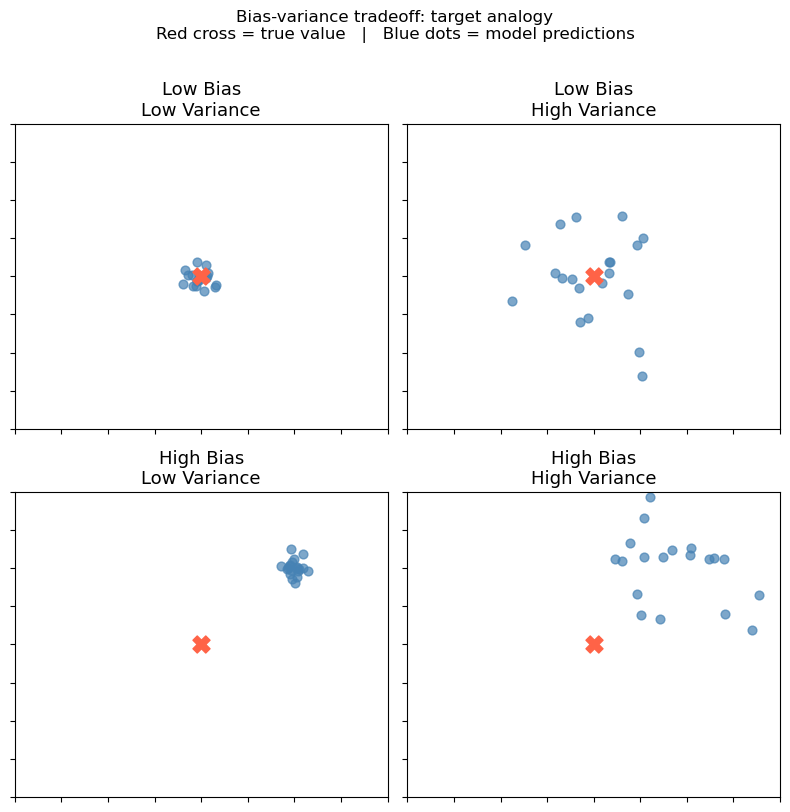

In [63]:
# Bias-variance diagram: the target analogy
# This figure shows four combinations of bias and variance.
# Each dot represents a prediction; the red cross is the true value.

fig, axs = plt.subplots(2, 2, figsize=(8, 8))

np.random.seed(42)
truth_x, truth_y = 0, 0
size = 20

low_b,  high_b  = 0,   1
low_v,  high_v  = 0.1, 0.5

configs = [
    (low_b,  low_v,  "Low Bias\nLow Variance",   (0, 0)),
    (low_b,  high_v, "Low Bias\nHigh Variance",  (0, 1)),
    (high_b, low_v,  "High Bias\nLow Variance",  (1, 0)),
    (high_b, high_v, "High Bias\nHigh Variance", (1, 1)),
]

for bias, var, label, (row, col) in configs:
    px = bias + var * np.random.randn(size)
    py = bias + var * np.random.randn(size)
    axs[row, col].scatter(truth_x, truth_y,
                          color='tomato', marker='X', s=150, zorder=5)
    axs[row, col].scatter(px, py,
                          color='steelblue', marker='o', s=40, alpha=0.7)
    axs[row, col].set_title(label, fontsize=13)
    axs[row, col].set_xlim([-2, 2])
    axs[row, col].set_ylim([-2, 2])
    axs[row, col].set_xticklabels([])
    axs[row, col].set_yticklabels([])

plt.suptitle("Bias-variance tradeoff: target analogy\n"
             "Red cross = true value   |   Blue dots = model predictions",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

Read the four panels from left to right and top to bottom:

- **Top left (low bias, low variance):** Predictions cluster tightly around the 
  true value. This is the ideal outcome.
- **Top right (low bias, high variance):** Predictions are centered near the 
  true value on average, but are spread out widely. The model is not 
  systematically wrong, but it is unstable.
- **Bottom left (high bias, low variance):** Predictions are consistently wrong 
  in the same direction, but they are tightly grouped. The model is stable 
  but systematically off.
- **Bottom right (high bias, high variance):** Predictions are both spread out 
  and shifted away from the true value. This is the worst case.

In practice, increasing model complexity moves you from the bottom-left pattern 
toward the top-right pattern. The degree 3 model from Part 3 sits closer to 
the top-left. The degree 13 model from Part 4 sits closer to the top-right.

## Part 6: Visualizing the tradeoff across model complexity

So far we have looked at three specific models: degree 1, degree 3, and degree 13. 
But what if we fit models at every level of complexity between those extremes and 
tracked how training and test error change? That gives us a much clearer picture 
of where the tradeoff happens.

The cell below fits polynomial models at every degree from 1 to 11 and records 
the training and test error for each one. Run it and study the resulting plot.

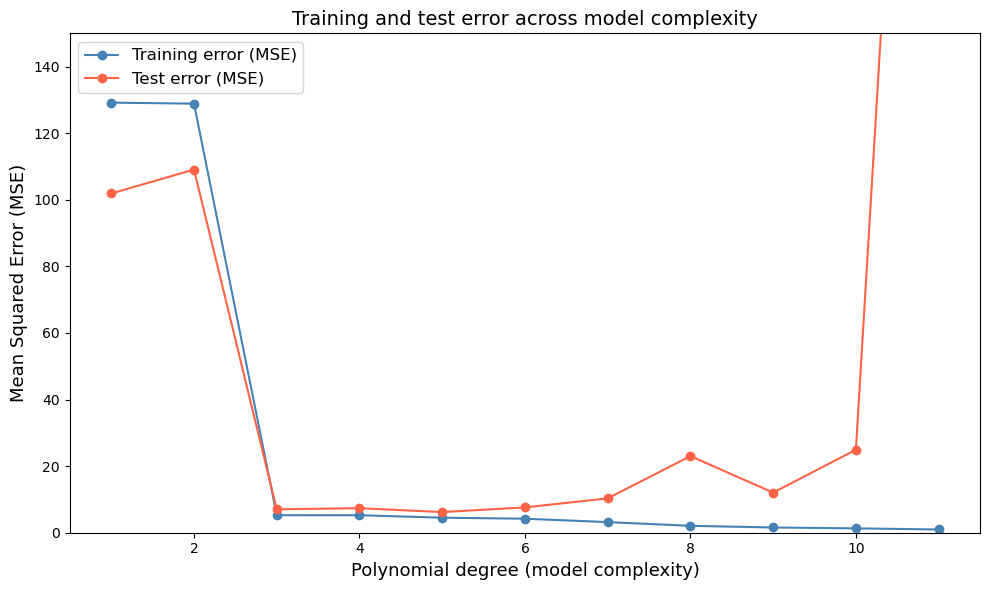

In [69]:
# Fit models at each polynomial degree from 1 to 11
# and record training and test error at each level

degrees = range(1, 12)
train_errors = []
test_errors  = []

for degree in degrees:
    model = make_pipeline(
        PolynomialFeatures(degree),
        StandardScaler(),
        LinearRegression()
    )
    model.fit(x_train.reshape(-1, 1), y_train)
    
    train_errors.append(mse(y_train, model.predict(x_train.reshape(-1, 1))))
    test_errors.append( mse(y_test,  model.predict(x_test.reshape(-1, 1))))

# Plot training and test error as a function of model complexity
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_errors, 'o-', color='steelblue', label='Training error (MSE)')
plt.plot(degrees, test_errors,  'o-', color='tomato',    label='Test error (MSE)')
plt.xlabel("Polynomial degree (model complexity)", fontsize=13)
plt.ylabel("Mean Squared Error (MSE)", fontsize=13)
plt.title("Training and test error across model complexity", fontsize=14)
plt.legend(fontsize=12)
plt.ylim(0, 150)
plt.tight_layout()
plt.show()

This plot captures the bias-variance tradeoff in a single image. A few things 
to notice:

- On the left side of the plot (low complexity), both training and test error 
  are high. This is the underfitting region: the model is too simple to capture 
  the underlying pattern.
- As complexity increases, both errors drop. There is a region where the model 
  is flexible enough to capture the real signal, and test error reaches its 
  lowest point.
- As complexity continues to increase beyond that point, training error keeps 
  falling but test error rises again. This is the overfitting region: the model 
  is starting to memorize noise rather than learn the pattern, and that hurts 
  its performance on new data.

The gap between the training and test error curves is a useful diagnostic. A 
large gap signals overfitting. No gap at all, with both errors high, signals 
underfitting.

**Try it** The y-axis is currently capped at 150 to keep the plot readable. 
Change `plt.ylim(0, 150)` to `plt.ylim(0, 500)` and re-run. What happens to 
the test error at the highest complexity levels? What does this tell you about 
how badly a highly overfit model can fail on new data?

## Part 7: Does more data help?

After seeing the overfitting result in Part 4, you might be wondering: what if 
we just collected more data? More observations should give the model more to 
learn from, which might reduce its tendency to memorize noise. This is a 
reasonable intuition, and it is partly correct. But the answer depends on 
which problem the model has.

The cell below generates a dataset ten times larger than the one we have been 
working with, using the same true function and the same amount of noise. We 
then refit both the underfit model (degree 1) and the overfit model (degree 13) 
on this larger dataset and compare the results to what we saw before.

In [71]:
# Generate a much larger dataset using the same true function and noise level

np.random.seed(42)
x_big = np.random.uniform(low=x_min, high=x_max, size=200)
y_big = true_function(x_big) + 3 * np.random.randn(200)

x_big_train, x_big_test, y_big_train, y_big_test = train_test_split(
    x_big, y_big, test_size=0.3, random_state=42)

print(f"Large dataset training samples: {len(x_big_train)}")
print(f"Large dataset test samples: {len(x_big_test)}")

Large dataset training samples: 140
Large dataset test samples: 60


First, let's refit the underfit model (degree 1) on the larger dataset.

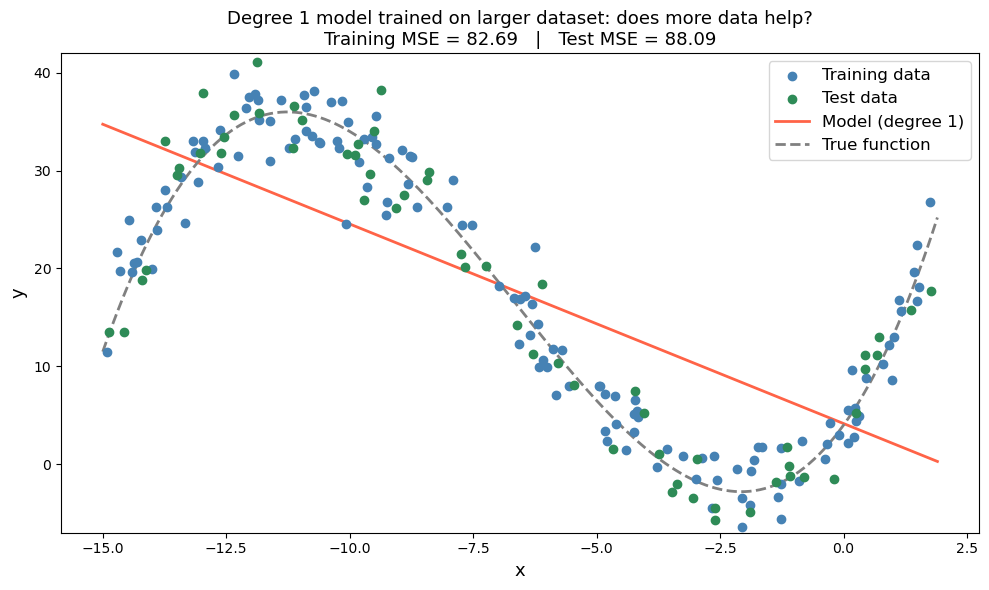

(82.68862501365668, 88.0900954722105)

In [72]:
# Degree 1 model trained on the larger dataset

fit_and_plot(
    x_big_train, y_big_train, x_big_test, y_big_test, x_plot, y_true,
    degree=1,
    title="Degree 1 model trained on larger dataset: does more data help?"
)

The straight line still cannot follow the curve in the data. Both the training 
and test errors remain high, and they are still close to each other. More data 
has not helped.

This is a critical point: when a model is underfitting, the problem is not the 
amount of data. The problem is the model's structure. No matter how many 
observations you collect, a straight line will never be able to represent a 
relationship that rises and falls. More data cannot fix high bias.

Now let's refit the overfit model (degree 13) on the larger dataset.

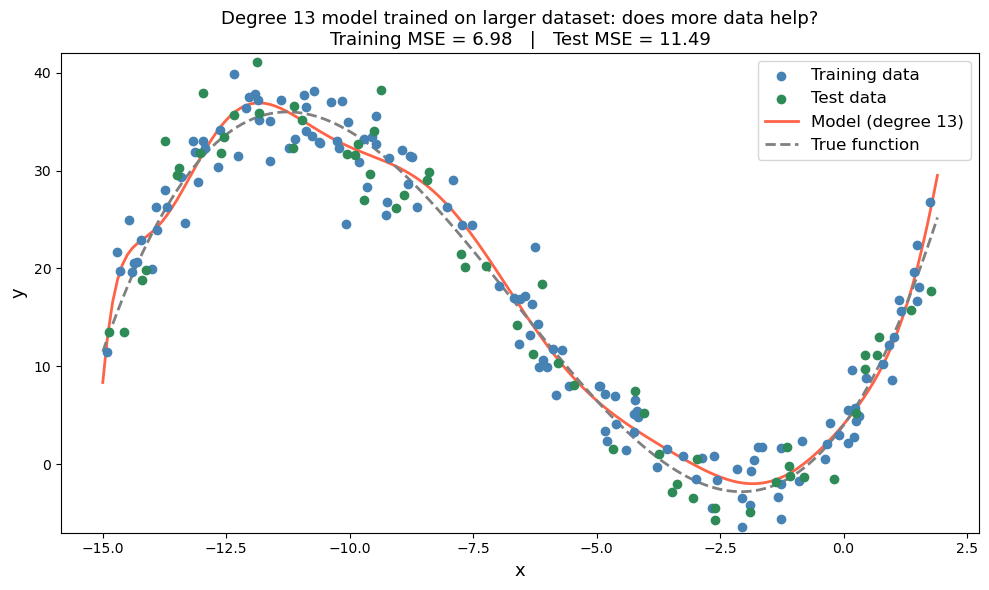

(6.979596152556783, 11.485630897612834)

In [73]:
# Degree 13 model trained on the larger dataset

fit_and_plot(
    x_big_train, y_big_train, x_big_test, y_big_test, x_plot, y_true,
    degree=13,
    title="Degree 13 model trained on larger dataset: does more data help?"
)

Here the result is different. With more data, the degree 13 model fits the 
true function much more closely, and the gap between training and test error 
is substantially smaller than it was with only 20 observations. More data has 
helped.

This is because overfitting is partly a consequence of having too few 
observations relative to model complexity. With only 20 training points, a 
degree 13 model has more than enough flexibility to memorize every quirk in 
the data. With 140 training points spread across the same range, there are 
too many observations for the model to memorize, and it is forced to learn 
the underlying pattern instead.

This has a direct parallel in biological research. In microbiome studies, for 
example, it is common to have datasets with hundreds or thousands of features 
(microbial taxa, genes, metabolites) but only dozens of samples. That 
combination, many features and few samples, creates exactly the conditions 
where overfitting is most likely to occur. In those situations, a simpler 
model is often not just easier to work with but genuinely more appropriate 
for the data you have.

**Try it** Go back to the original dataset (with 20 observations) and the 
larger dataset (with 200 observations). What was the test error for the 
degree 13 model on each dataset? How much did it change? Does the degree 1 
model show a similar improvement with more data?